# Processed data exploration

Walks through the **sanitised CSVs** living under
`data/processed/{pd,lgd}/<dataset_id>.sanitized.csv` plus the two
manifests at `data/manifest_{pd,lgd}.csv`. The story this notebook
tells is *did the sanitisation produce sensible inputs?*

**Designed for the 3 000-dataset corpus.** Every plot here is
either a corpus-level histogram or a paginated per-dataset view
with a strict `max_show` budget. We deliberately do NOT plot
per-feature distributions, missingness heatmaps, or correlation
heatmaps — those don't visualise meaningfully across thousands of
datasets.

## What 'missingness' means here

`missing_rate_raw` is the **fraction of cells** that are NaN, with
`cell_count = n_rows × n_features`. Computed by `register.py` on
the post-fix DataFrame and stored in the manifest. It is *not*
the fraction of rows that contain at least one NaN.

## What 'source' means here

Comes from the `DATASET_METADATA` dict literal in
`src/data/preprocessing.py`, hand-curated per dataset and carried
forward into the manifest verbatim by `register.py`.

## Sections

1. Corpus summary table (memoised)
2. Dataset shape — separate plots PD / LGD
3. Missingness — separate plots PD / LGD
4. Corpus-level target stats
5. Per-dataset target distribution — **LGD only**
6. Anomaly scan

**No per-PD per-dataset target plot** — for binary targets the
corpus-level minority-class-share histogram in section 4 conveys
the same information much more compactly. LGD's continuous target
*does* benefit from a per-dataset histogram (bimodality structure),
so that one is kept.

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
while not (REPO / 'src' / 'data' / 'exploration.py').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import pandas as pd
from src.data.exploration import (
    corpus_summary_table, clear_summary_cache,
    plot_dataset_size_distribution, plot_missing_rate_distribution,
    plot_class_imbalance_distribution, plot_target_mean_distribution_lgd,
    plot_target_distribution_lgd,
    find_anomalous_datasets,
)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

from src.utils.figures import open_figure_sink
sink = open_figure_sink('0.1_processed_data_exploration')


## 1. Corpus summary table (memoised)

One row per dataset, both tracks together. `raw_*` columns reflect
the manifest (post-fix); `post_*` columns reflect what's actually
on disk after sanitisation. Float columns are rounded to 4
decimals.

In [2]:
summary = corpus_summary_table()
summary

,track,dataset_id,task_type,target_column,raw_rows,raw_features,post_rows,post_features,n_categorical,n_numerical,missing_rate_raw,minority_class_ratio,target_mean,target_std,source
0,pd,0001.gmsc,classification,SeriousDlqin2yrs,150000,10,150000,10,0,10,0.0224,0.0668,NaN,NaN,kaggle
1,pd,0002.taiwan_creditcard,classification,default.payment.next.month,30000,23,30000,23,0,23,0.0000,0.2212,NaN,NaN,uci
2,pd,0003.vehicle_loan,classification,loan_default,233154,33,233154,33,3,30,0.0010,0.2171,NaN,NaN,kaggle
3,pd,0004.lendingclub,classification,not.fully.paid,9578,13,9578,13,1,12,0.0000,0.1601,NaN,NaN,lendingclub
4,pd,0005.myhom,classification,loan_default,7000,8,7000,8,1,7,0.0044,0.4000,NaN,NaN,local
5,pd,0006.hackerearth,classification,loan_status,532428,37,532428,36,10,27,0.0923,0.2363,NaN,NaN,hackerearth
6,pd,0007.cobranded,classification,default_ind,80000,47,80000,47,0,47,0.1884,0.2462,NaN,NaN,local
7,pd,0008.german,classification,target,999,20,999,20,13,7,0.0000,0.3003,NaN,NaN,uci
8,pd,0009.bank_status,classification,Loan Status,100000,16,100000,16,0,16,0.0609,0.2264,NaN,NaN,kaggle
9,pd,0010.thomas,classification,BAD,1225,14,1225,14,2,12,0.0000,0.2637,NaN,NaN,thomas-credit-textbook


---

## 2. Dataset shape — per track

PD and LGD shown separately. Row counts are log-scaled.

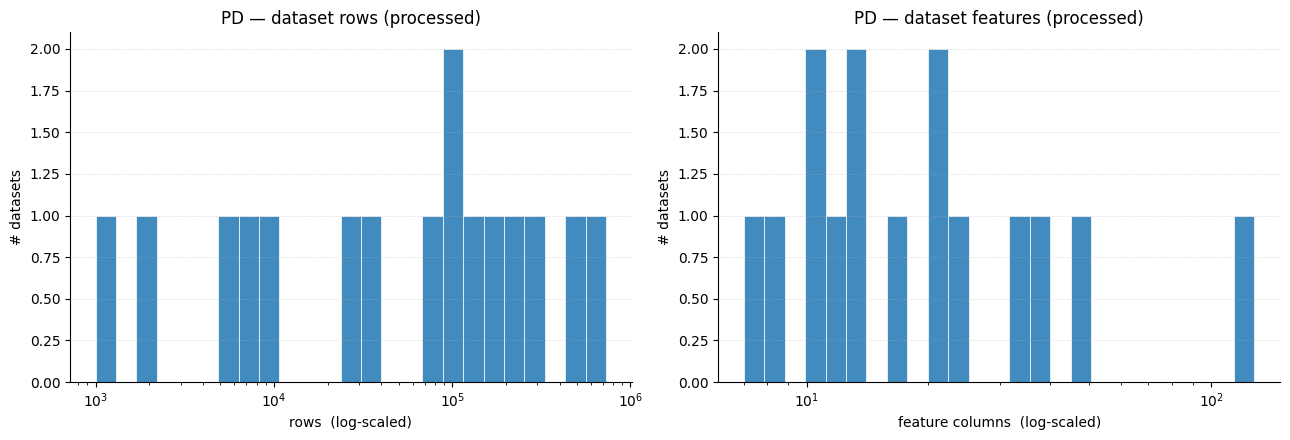

In [3]:
sink.save(plot_dataset_size_distribution('pd',  source='processed'), '01_dataset_size_distribution')

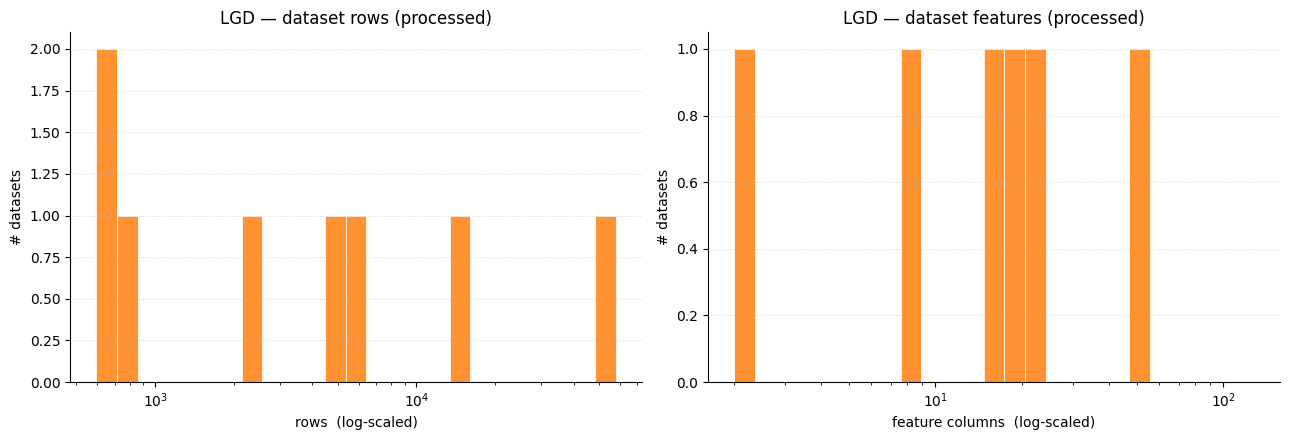

In [4]:
sink.save(plot_dataset_size_distribution('lgd', source='processed'), '02_dataset_size_distribution')

## 3. Missingness — per track

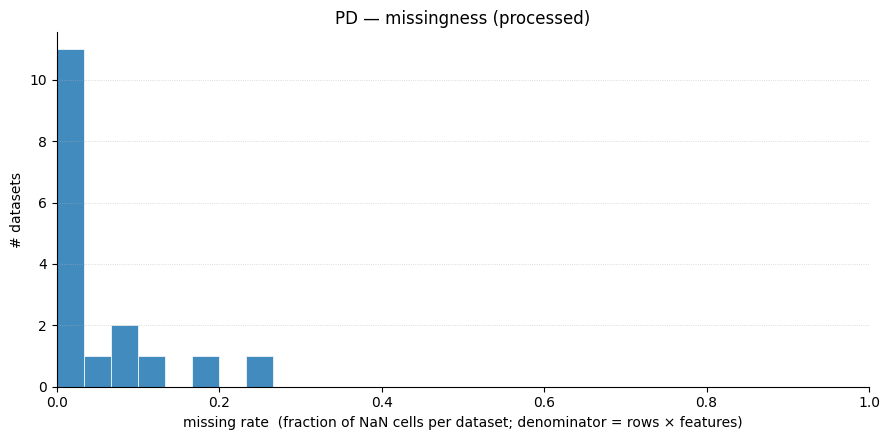

In [5]:
sink.save(plot_missing_rate_distribution('pd',  source='processed'), '03_missing_rate_distribution')

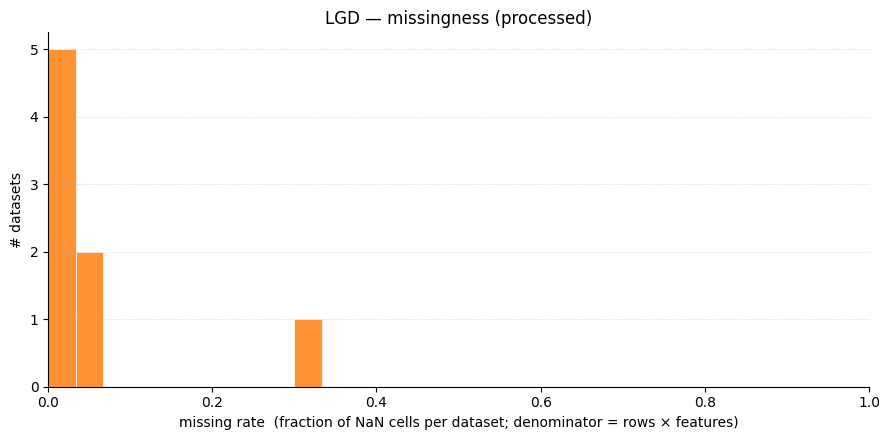

In [6]:
sink.save(plot_missing_rate_distribution('lgd', source='processed'), '04_missing_rate_distribution')

---

## 4. Corpus-level target stats

PD: histogram of minority-class share across all PD datasets — one
point per dataset. This is the corpus-level view of class
imbalance that scales to 3 000 datasets, replacing the per-dataset
bar chart we used to show.

LGD: histogram of dataset-level target means.

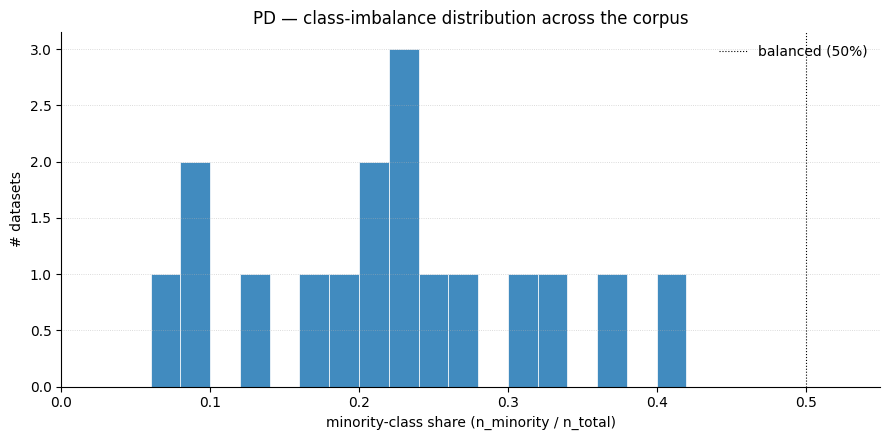

In [7]:
sink.save(plot_class_imbalance_distribution(), '05_class_imbalance_distribution')

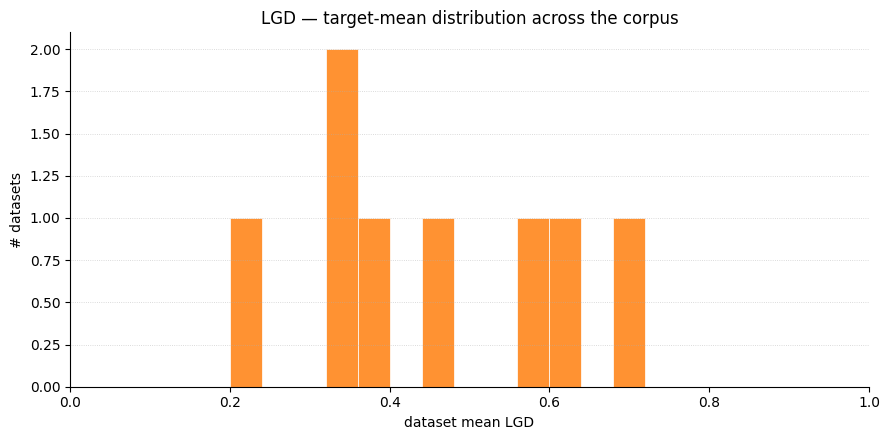

In [8]:
sink.save(plot_target_mean_distribution_lgd(), '06_target_mean_distribution_lgd')

---

## 5. Per-dataset target distribution — LGD only

Loss Given Default targets are real-valued in `[0, 1]`. Look for
the bimodal shape: mass at 0 (full recovery) and at 1 (total
loss). The interior is what TabPFN's regression head must model.
TabPFN-2.5 ships specialist `_low-skew` and `_quantiles` checkpoints
for exactly this kind of heavy-tailed target.

Default: first 30 LGD datasets. Pass `dataset_ids=[...]` for a
specific subset; raise `max_show` to page further. PD datasets
are intentionally not shown per-dataset — see section 4 for the
corpus-level alternative.

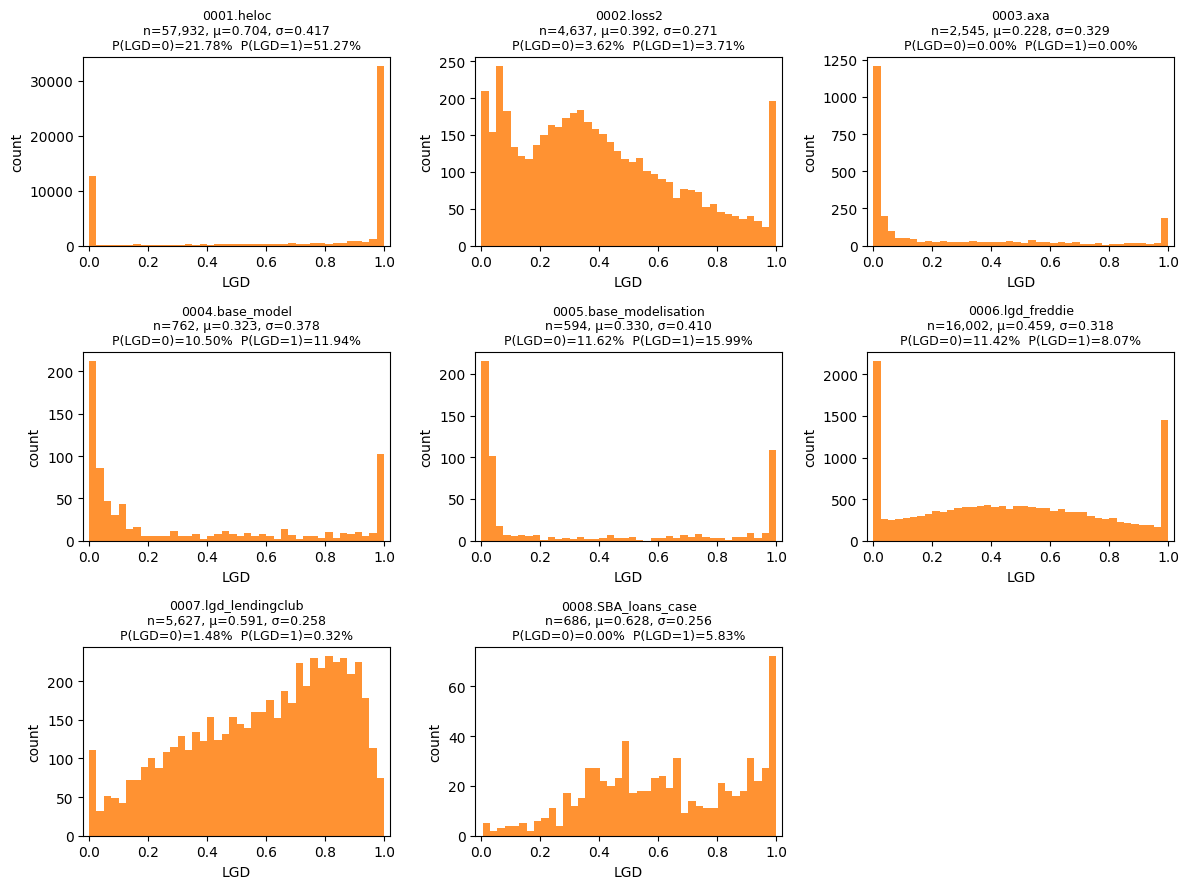

In [9]:
sink.save(plot_target_distribution_lgd(max_show=30), '07_target_distribution_lgd')

---

## 6. Anomaly scan

Identifies datasets that deserve a manual look — empty after
sanitisation, too few rows, very high missingness, severely
imbalanced, constant target, or zero feature columns.

In [10]:
anomalies = find_anomalous_datasets()
if len(anomalies) == 0:
    print('No anomalies flagged across the corpus.')
else:
    display(anomalies)

No anomalies flagged across the corpus.
